# Model project: Consumer with nested CES preferences

in this project we analyse a conusmer who allocate income between food and transport(Bus and Train).  

we consider two diffrent calibrations: 

**Compliments** Bus and train are goods which are **difficult** to substitute ("Sigma_B = 0.40")

**substitutes** Bus and train are goods which are **easy** to substitute ("Sigma_B = 3.00")



## 1. Setup of the two calibrations. 

We import the consumer model and the plotting functions. Then we create two versions of the same model. the two models only differ in how easily, the consumer can substitute between the two transport options.

In [25]:
import pandas as pd
import numpy as np
from ConsumerModelProject import ConsumerClass 
from FiguresModelProject import plot_grid, plot_convergencepath

print("\nModel 1: Complements")
model_complements = ConsumerClass()
print(model_complements)

print("\nModel 2: Substitutes")
model_substitutes = ConsumerClass(par={"sigma_B" : 3.})
print(model_substitutes)



Model 1: Complements
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

Model 2: Substitutes
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


# 2. Solving the model nuerically

## 2.1 a two dimensional grid search 
we solve the consumer problem using grid search. The method lay a grid over a chosen amount of possible budget shares for food, bus and train, and selects the combination wwith the highest utility




In [26]:
N = 50
opt_grid_complements = model_complements.solve_grid(N=N)
opt_grid_substitutes = model_substitutes.solve_grid(N=N)

grid_results = pd.DataFrame({
    "Model": ["complements", "Substitutes"],
    "s1 (food)": [
        opt_grid_complements.s1,
        opt_grid_substitutes.s1
    ],
     "w (bus share of transport)": [
            opt_grid_complements.w,
            opt_grid_substitutes.w
    ],
      "s2 (bus)": [
             opt_grid_complements.s2,
             opt_grid_substitutes.s2
    ],
       "s3 (train)": [
              opt_grid_complements.s3,
              opt_grid_substitutes.s3
    ],
     "u (utility)": [
            opt_grid_complements.u,
            opt_grid_substitutes.u
    ]
})

display(grid_results.style.format("{:.4f}", subset=[
    "s1 (food)", "w (bus share of transport)", "s2 (bus)", "s3 (train)", "u (utility)"
]).hide(axis="index"))

grid search with (2500 evaluations)
  s1 = 0.530612, w = 0.448980
  shares: 0.530612, 0.210746, 0.258642 (sum = 1.000000)
  u = 3.400748
grid search with (2500 evaluations)
  s1 = 0.530612, w = 0.693878
  shares: 0.530612, 0.325698, 0.143690 (sum = 1.000000)
  u = 3.484594


Model,s1 (food),w (bus share of transport),s2 (bus),s3 (train),u (utility)
complements,0.5306,0.4490,0.2107,0.2586,3.4007
Substitutes,0.5306,0.6939,0.3257,0.1437,3.4846


## Complements 
53,06% goes to food 21,07% goes to bus tickets, and 25,86% goes to train tickets. since the two transport options compliment each other, the consumer allocates the transport budget relativly evenly between the two. The higher budget share for train, can be eplained due to train ticket being more expesive than bus tickets. 

## substitutes 
53,06% goes to food 32,57% goes to bus tickets, and 14,37% goes to train tickets. The consumer allocates more to the cheaper transport which is bus. This can be explained due to it beng easier for the consumer to replace train trips with bus triops, when the substituion elasticity is higher. 

###2.1.2
We now plot the utility over the nested shares.   

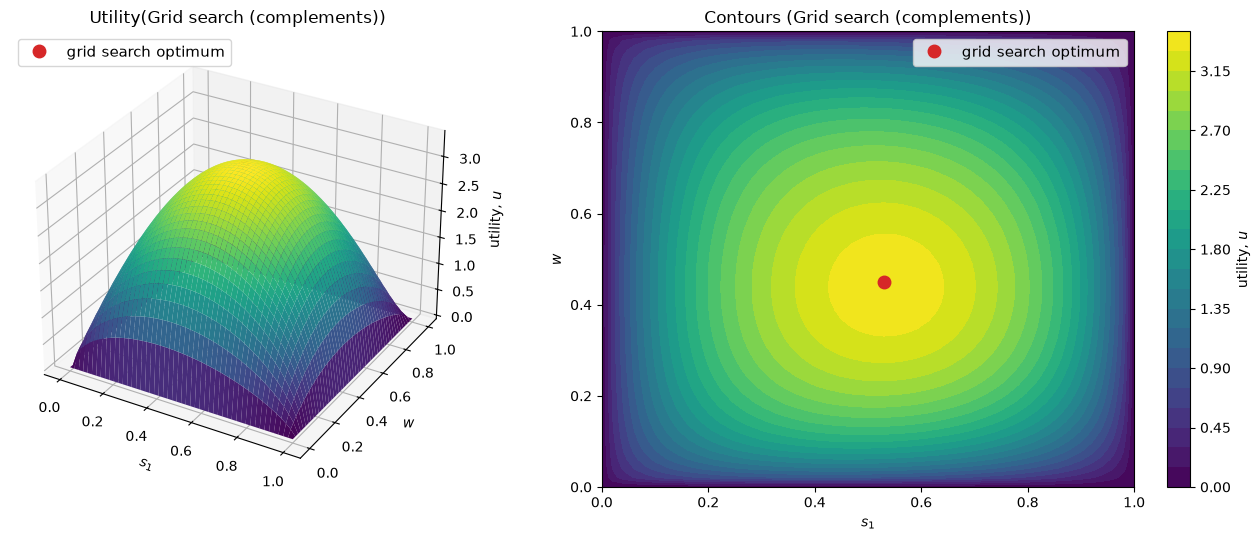

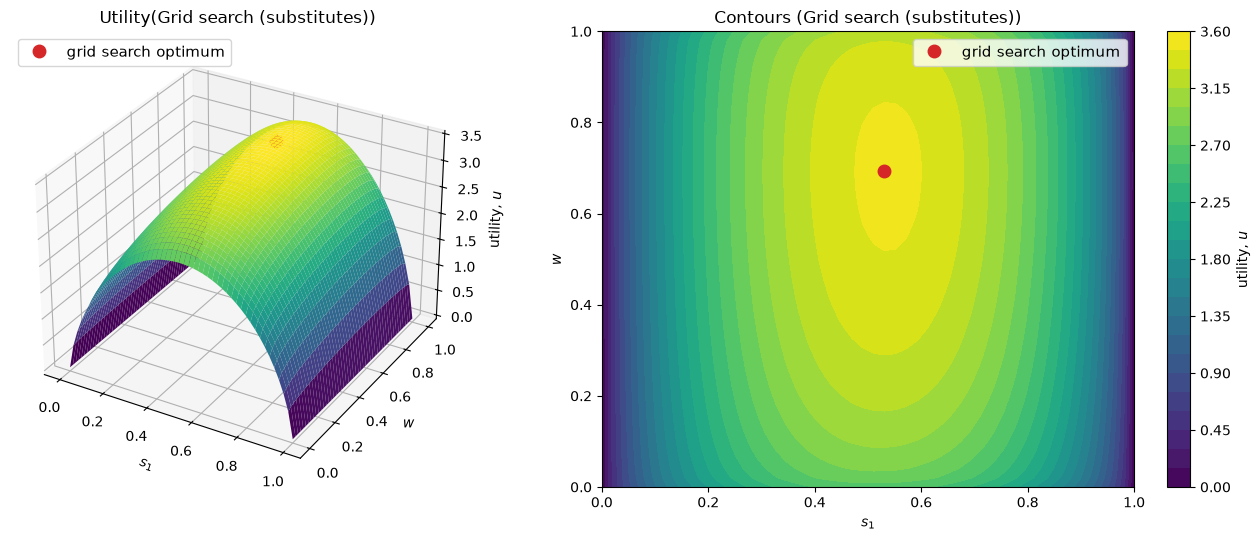

In [27]:
plot_grid(opt_grid_complements, title="Grid search (complements)")
plot_grid(opt_grid_substitutes, title="Grid search (substitutes)")


###2.1.3
We increace the number of grid point to examine how much this affect our answers. 


In [28]:
N_values = [50, 100, 500, 1000]
results = []
for N in N_values:
    opt_complements = model_complements.solve_grid(N=N)
    opt_substitutes = model_substitutes.solve_grid(N=N)

    results.append({
    "N": N,
    "Utility evaluations": N**2,
    "Model": "Complements",
    "s1 (food)": opt_complements.s1,
    "w (bus share of transport)": opt_complements.w,
    "Utility": opt_complements.u    
    })

    results.append({
    "N": N,
    "Utility evaluations": N**2,
    "Model": "Substitutes",
    "s1 (food)": opt_substitutes.s1,
    "w (bus share of transport)": opt_substitutes.w,
    "Utility": opt_substitutes.u    
    })

N_results = pd.DataFrame(results)

display(
    N_results.style.format({
        "s1 (food)": "{:.4f}",
        "w (bus share of transport)": "{:.4f}",
        "Utility": "{:.4f}"
    }).hide(axis="index")
)

grid search with (2500 evaluations)
  s1 = 0.530612, w = 0.448980
  shares: 0.530612, 0.210746, 0.258642 (sum = 1.000000)
  u = 3.400748
grid search with (2500 evaluations)
  s1 = 0.530612, w = 0.693878
  shares: 0.530612, 0.325698, 0.143690 (sum = 1.000000)
  u = 3.484594
grid search with (10000 evaluations)
  s1 = 0.535354, w = 0.444444
  shares: 0.535354, 0.206510, 0.258137 (sum = 1.000000)
  u = 3.401482
grid search with (10000 evaluations)
  s1 = 0.535354, w = 0.696970
  shares: 0.535354, 0.323845, 0.140802 (sum = 1.000000)
  u = 3.485005
grid search with (250000 evaluations)
  s1 = 0.535070, w = 0.438878
  shares: 0.535070, 0.204047, 0.260882 (sum = 1.000000)
  u = 3.401674
grid search with (250000 evaluations)
  s1 = 0.539078, w = 0.691383
  shares: 0.539078, 0.318673, 0.142248 (sum = 1.000000)
  u = 3.485097
grid search with (1000000 evaluations)
  s1 = 0.535536, w = 0.439439
  shares: 0.535536, 0.204104, 0.260360 (sum = 1.000000)
  u = 3.401680
grid search with (1000000 evalua

N,Utility evaluations,Model,s1 (food),w (bus share of transport),Utility
50,2500,Complements,0.5306,0.4490,3.4007
50,2500,Substitutes,0.5306,0.6939,3.4846
100,10000,Complements,0.5354,0.4444,3.4015
100,10000,Substitutes,0.5354,0.6970,3.4850
500,250000,Complements,0.5351,0.4389,3.4017
500,250000,Substitutes,0.5391,0.6914,3.4851
1000,1000000,Complements,0.5355,0.4394,3.4017
1000,1000000,Substitutes,0.5385,0.6927,3.4851


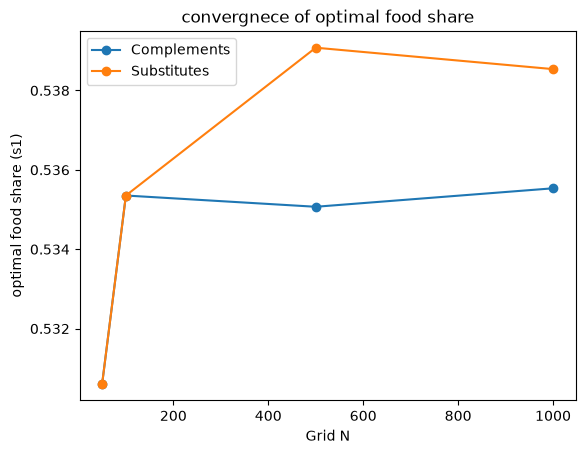

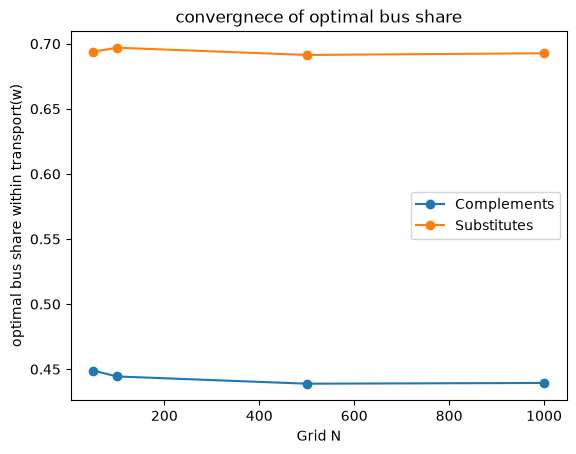

In [29]:

# we now plot the results
import matplotlib.pyplot as plt 

for model in ["Complements", "Substitutes"]:
    data = N_results[N_results["Model"] == model]
    plt.plot(data["N"], data["s1 (food)"], marker="o",
    label=model)

plt.xlabel("Grid N")
plt.ylabel("optimal food share (s1)")
plt.title("convergnece of optimal food share")
plt.legend()
plt.show()


for model in ["Complements", "Substitutes"]:
    data = N_results[N_results["Model"] == model]
    plt.plot(data["N"], data["w (bus share of transport)"], marker="o",
    label=model)

plt.xlabel("Grid N")
plt.ylabel("optimal bus share within transport(w)")
plt.title("convergnece of optimal bus share")
plt.legend()
plt.show()



The plots above show the results for solving the model using increasingly fine grids with (N= 50, 100, 500, 1000)

The results shows that the optimal share becomes relativly more stable as N increases. In the complements model food share and bus share within transport, converges to respectively approximately 0,535, and 0.439. In the substitutes model food share and bus share within transport converges to respectively approximately 0,539, and 0.693

The solution does not improve perfectly smooth which becomes clear in the graphs. This makes sence since grid seach can only choose among the descrete points included. 

The number evaluations of u increases quadratically with the grid size. the number of evaluation increases from (N = 50) with 2.500 evaluation, to (N = 1000) with 1.000.000 evaluations. 






### 2.1.4 
From the plots in 2.1.2 it is clear that the complements model has a steeper utility surface around the optimum, while the substitutes model i flatter in the w direction. This implies that the substitutes model i likely harder to optimize, since many different bus/train allocations results in almost the same utillity 

## 2.2 L-BFGS-B
### 2.2.1 Compare L-BFGS-B with grid search
We now solve the model using L-BFGS-B. The method searches for the optimal values of \(s_1\) and \(w\) between 0 and 1.

We compare the result with the grid search.

In [30]:
models = {'Complements': model_complements,'Substitutes': model_substitutes}

import time

rows = []

for name, model in models.items():

    # Grid search
    start = time.perf_counter()
    grid = model.solve_grid(N=1000, do_print=False)
    grid_time = time.perf_counter() - start

    # L-BFGS-B
    start = time.perf_counter()
    opt = model.solve(do_print=False)
    opt_time = time.perf_counter() - start

    rows.append([name, grid.s1, grid.w, opt.s1, opt.w, 1000**2, opt.res.nfev, grid_time, opt_time])

comparison = pd.DataFrame(rows, columns=['Calibration','Grid s1','Grid w','L-BFGS-B s1','L-BFGS-B w','Grid evaluations','L-BFGS-B evaluations','Grid time','L-BFGS-B time'])

comparison

,Calibration,Grid s1,Grid w,L-BFGS-B s1,L-BFGS-B w,Grid evaluations,L-BFGS-B evaluations,Grid time,L-BFGS-B time
0,Complements,0.535536,0.439439,0.535623,0.439479,1000000,18,0.066257,0.003586
1,Substitutes,0.538539,0.692693,0.538225,0.692308,1000000,27,0.060002,0.001514


The grid search and L-BFGS-B give almost the same solution for both calibrations.

However, L-BFGS-B is much more efficient. The grid search uses 1,000,000 function evaluations, while L-BFGS-B only uses 18 for complements and 27 for substitutes. L-BFGS-B is also much faster.

Therefore, the two methods agree, but L-BFGS-B finds the solution more efficiently.

### 2.2.2 Convergence path

We now study how L-BFGS-B moves from the starting point toward the final solution.

We show the path on the contour plot and calculate the distance from each iteration to the final point.

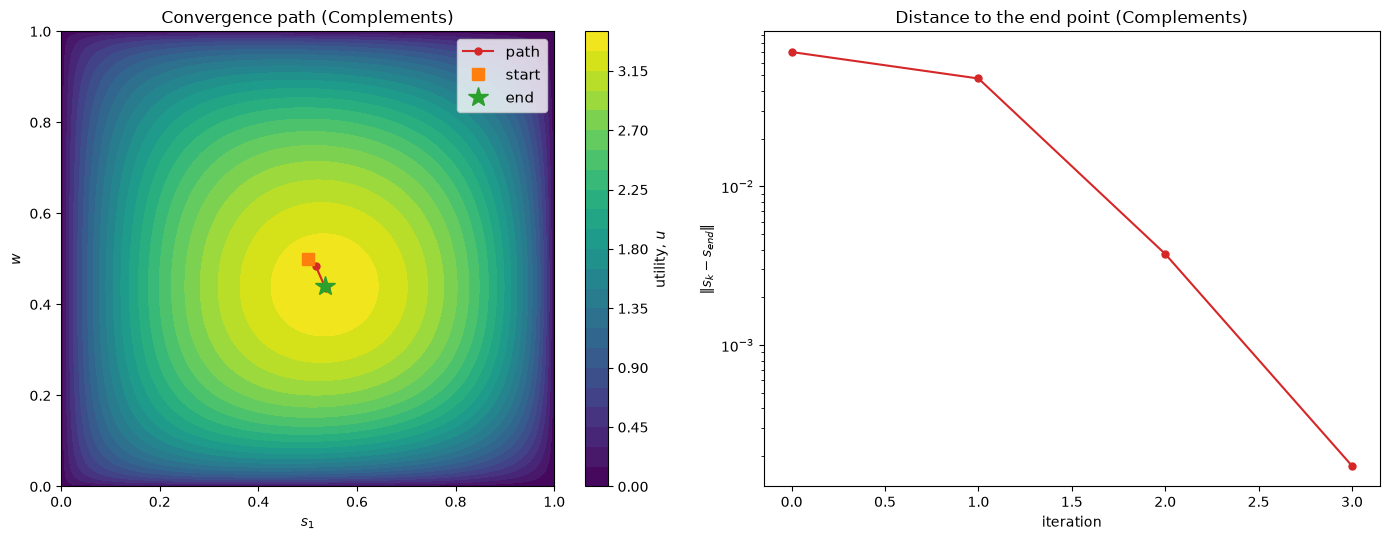

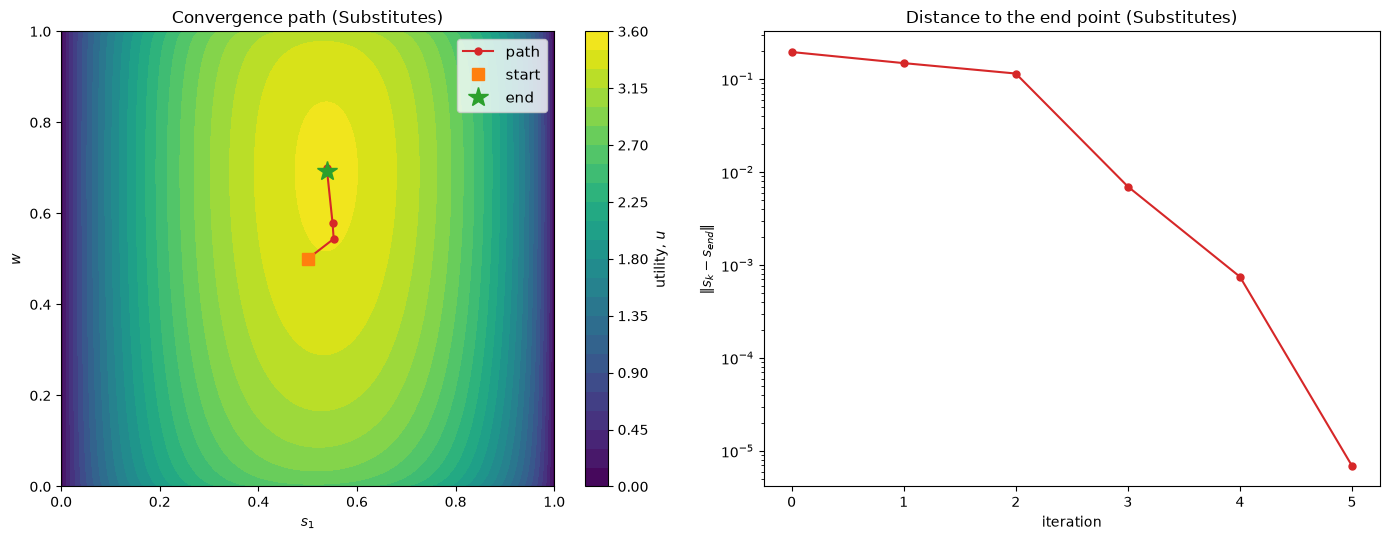

In [31]:
opt_complements = model_complements.solve(do_print=False)
opt_substitutes = model_substitutes.solve(do_print=False)

grid_complements = model_complements.solve_grid(N=200, do_print=False)
grid_substitutes = model_substitutes.solve_grid(N=200, do_print=False)

plot_convergencepath(grid_complements,opt_complements,'Complements')

plot_convergencepath(grid_substitutes,opt_substitutes,'Substitutes')

The optimizer converges to the optimum in both calibrations.

For the complements calibration, the optimizer makes some progress in the first iteration and then quickly moves close to the final solution. The distance falls strongly in the last iterations.

For the substitutes calibration, progress is slower in the first iterations. After this, the distance to the final solution decreases rapidly.

Overall, L-BFGS-B makes fast progress once it finds the direction towards the optimum, while progress is slower in the first iterations, especially for the substitutes calibration.

### 2.2.3 Different starting points

The result of a numerical optimizer can depend on its starting point. We therefore solve the model from several different starting values and compare the results.

In [32]:
starting_points = [(0,0),(0,1),(1,0),(1,1),(0.5,0.5),(0.25,0.75)]

rows = []

for name, model in models.items():

    for s0 in starting_points:

        opt = model.solve(s0=np.array(s0),do_print=False)

        rows.append([name,s0,opt.s1,opt.w,opt.u,opt.res.nit,opt.res.success])

starting_results = pd.DataFrame(rows, columns=['Calibration','Starting point','s1','w','Utility','Iterations','Success'])

starting_results

,Calibration,Starting point,s1,w,Utility,Iterations,Success
0,Complements,"(0, 0)",0.535624,0.439478,3.401680e+00,7,True
1,Complements,"(0, 1)",0.535624,0.439478,3.401680e+00,9,True
2,Complements,"(1, 0)",0.999991,0.000000,6.177357e-11,1,True
3,Complements,"(1, 1)",0.999991,1.000000,6.177357e-11,1,True
4,Complements,"(0.5, 0.5)",0.535623,0.439479,3.401680e+00,4,True
5,Complements,"(0.25, 0.75)",0.535624,0.439479,3.401680e+00,6,True
6,Substitutes,"(0, 0)",0.538225,0.692305,3.485105e+00,18,True
7,Substitutes,"(0, 1)",0.538225,0.692308,3.485105e+00,17,True
8,Substitutes,"(1, 0)",0.538225,0.692308,3.485105e+00,18,True
9,Substitutes,"(1, 1)",0.538225,0.692308,3.485105e+00,16,True


Most starting points converge to the same optimum, but the number of iterations changes.

For the complements calibration, the starting points \((1,0)\) and \((1,1)\) fail: utility is almost zero, even though `success = True`.

### 2.2.4 Tolerance settings

We now study how the stopping criteria affect the numerical solution.

`ftol` controls when the optimizer stops because the objective changes very little, while `gtol` controls when the gradient becomes sufficiently small.

In [33]:
def tolerance_table(model):

    rows = []

    ftols = [1e-4, 1e-8, 1e-12, 1e-16]
    gtols = [1e-2, 1e-5, 1e-8, 1e-12]

    for value in ftols:

        opt = model.solve(do_print=False,options={'ftol': value})

        rows.append(['ftol',value,opt.s1,opt.w,opt.u,opt.res.nfev])

    for value in gtols:

        opt = model.solve(do_print=False,options={'gtol': value})

        rows.append(['gtol',value,opt.s1,opt.w,opt.u,opt.res.nfev])

    return pd.DataFrame(rows, columns=['Tolerance','Value','s1','w','Utility','Evaluations'])

tolerance_table(model_complements)

tolerance_table(model_substitutes)

,Tolerance,Value,s1,w,Utility,Evaluations
0,ftol,1.000000e-04,0.538155,0.691562,3.485104,21
1,ftol,1.000000e-08,0.538225,0.692308,3.485105,27
2,ftol,1.000000e-12,0.538225,0.692308,3.485105,27
3,ftol,1.000000e-16,0.538225,0.692308,3.485105,27
4,gtol,1.000000e-02,0.538155,0.691562,3.485104,21
5,gtol,1.000000e-05,0.538225,0.692308,3.485105,27
6,gtol,1.000000e-08,0.538225,0.692308,3.485105,27
7,gtol,1.000000e-12,0.538225,0.692308,3.485105,27


The tighter tolerances only improve utility slightly. From `ftol = 1e-8` and `gtol = 1e-5`, the solution is almost unchanged.

Therefore, very tight tolerances are unnecessary because they do not meaningfully improve the result.

### 2.2.5 Choice of tolerance



We would use moderate tolerance values such as `ftol = 1e-8` and `gtol = 1e-5`. These values give almost the same utility as the tighter tolerance settings, while requiring fewer function evaluations.

A tighter tolerance is therefore not always better because it can increase the computational cost without giving a meaningful improvement in utility.

## 3. Relative prices and demand

### 3.1 Train prices, budget shares and quantities

We now change the price of train tickets, \(p_3\), from 0.5 to 3.0.

For each price, we solve the model and study how the budget shares and quantities change for complements and substitutes.

In [34]:
p3_values = np.linspace(0.5,3.0,50)

results = []

for name, sigma_B in [('Complements',0.4),('Substitutes',3.0)]:

    for p3 in p3_values:

        model = ConsumerClass(par={'sigma_B':sigma_B,'p3':p3})
        opt = model.solve(do_print=False)

        x1,x2,x3 = model.quantities(opt.s1,opt.w)

        results.append([name,p3,opt.s1,opt.s2,opt.s3,x1,x2,x3])

demand = pd.DataFrame(results,columns=['Calibration','p3','s1','s2','s3','x1','x2','x3'])

##### Budgetshares:

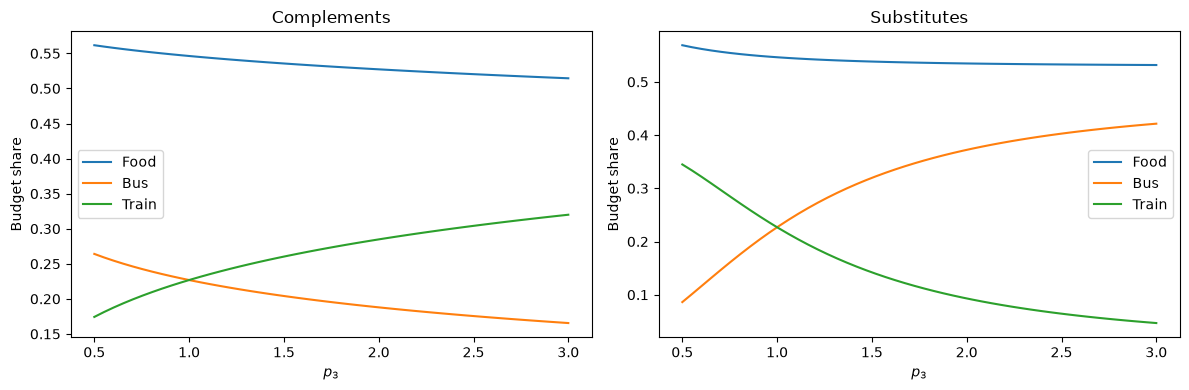

In [35]:
fig,axes = plt.subplots(1,2,figsize=(12,4))

for ax,(name,data) in zip(axes,demand.groupby('Calibration')):

    ax.plot(data.p3,data.s1,label='Food')
    ax.plot(data.p3,data.s2,label='Bus')
    ax.plot(data.p3,data.s3,label='Train')

    ax.set_title(name)
    ax.set_xlabel('$p_3$')
    ax.set_ylabel('Budget share')
    ax.legend()

plt.tight_layout()
plt.show()

##### Quantites:

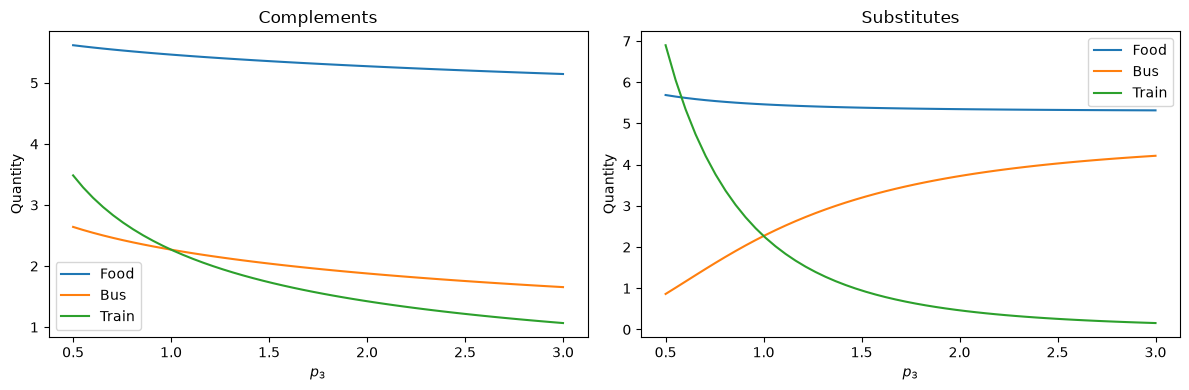

In [36]:
fig,axes = plt.subplots(1,2,figsize=(12,4))

for ax,(name,data) in zip(axes,demand.groupby('Calibration')):

    ax.plot(data.p3,data.x1,label='Food')
    ax.plot(data.p3,data.x2,label='Bus')
    ax.plot(data.p3,data.x3,label='Train')

    ax.set_title(name)
    ax.set_xlabel('$p_3$')
    ax.set_ylabel('Quantity')
    ax.legend()

plt.tight_layout()
plt.show()

### 3.2 Train budget share

For complements, the train budget share increases when p_3 rises. Even though train trips become more expensive, the consumer still wants to combine train and bus travel.

For substitutes, the train budget share decreases because the consumer can switch away from trains and spend more on bus trips.

### 3.3 Bus trips
For complements, bus demand falls when train tickets become more expensive. Since bus and train are used together, a higher train price reduces demand for both travel goods.

For substitutes, bus demand rises strongly. The consumer replaces expensive train trips with bus trips.

### 3.4 Food demand
Food demand falls slightly in both calibrations when p_3 rises. However, the change in food demand is small compared with the change in bus demand. The strongest response is therefore within the travel nest, especially when bus and train are substitutes.

## 4. Lump-sum taxes and product taxes

The government now needs to raise tax revenue.

We compare a lump-sum tax with different product taxes. Taxes change the consumer's income or prices, which then changes demand and utility.

### 4.1 Tax revenue

We first implement total tax revenue. Revenue consists of the lump-sum tax plus revenue from taxes on food, bus and train.

In [37]:
gov_complements = GovernmentClass()

gov_complements.set_taxes(tau1=0.10)

R = gov_complements.tax_revenue()

print(f'Tax revenue = {R:.4f}')

NameError: name 'GovernmentClass' is not defined

### 4.2

In [ ]:

instruments = {'Food only':(1,), 'Bus only':(2,), 'Train only':(3,),
               'Bus and train':(2,3), 'All three':(1,2,3)}

tau_vec = np.linspace(0,3.0,100)

R = {}
u = {}

for model,cal in [(model_c,'complements'),(model_s,'substitutes')]:
    for name,goods in instruments.items():
        R[cal,name] = np.empty(tau_vec.size)
        u[cal,name] = np.empty(tau_vec.size)
        for i,tau in enumerate(tau_vec):
            R[cal,name][i],u[cal,name][i] = model.revenue_and_utility(tau,goods)

### 4.3

In [ ]:
tau,R_max = model_s.max_revenue(goods=(3,),tau_max=3.0)

### 4.4

In [ ]:
T_vec = np.linspace(0,3.0,100)

for model,cal in [(model_c,'complements'),(model_s,'substitutes')]:
    R[cal,'Lump-sum'] = np.empty(T_vec.size)
    u[cal,'Lump-sum'] = np.empty(T_vec.size)
    for i,T in enumerate(T_vec):
        R[cal,'Lump-sum'][i],u[cal,'Lump-sum'][i] = model.revenue_and_utility_lump_sum(T)

### 4.5

In [ ]:
tau = model_c.find_tax_rate(0.20,goods=(2,))
R,u = model_c.revenue_and_utility(tau,goods=(2,))